------

------

# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
import pandas as pd# importar librerías

In [2]:
instacart_orders = pd.read_csv("/datasets/instacart_orders.csv", sep=";")
products = pd.read_csv("/datasets/products.csv", sep=";")
aisles = pd.read_csv("/datasets/aisles.csv", sep=";")
departments = pd.read_csv("/datasets/departments.csv", sep=";")
order_products = pd.read_csv("/datasets/order_products.csv", sep=";")
# leer conjuntos de datos en los DataFrames

In [3]:
print(instacart_orders.head())# mostrar información del DataFrame

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  


In [4]:
print(products.head())# mostrar información del DataFrame

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


In [5]:
print(aisles.head())# mostrar información del DataFrame

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [6]:
print(departments.head())# mostrar información del DataFrame

   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [7]:
print(order_products.head())# mostrar información del DataFrame

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

In [8]:
#para order "ID´s"
instacart_orders['order_id'] = pd.to_numeric(instacart_orders['order_id'], errors='coerce').astype('Int64')
instacart_orders['user_id'] = pd.to_numeric(instacart_orders['user_id'], errors='coerce').astype('Int64')
instacart_orders['order_number'] = pd.to_numeric(instacart_orders['order_number'], errors='coerce').astype('Int64')
instacart_orders['order_dow'] = pd.to_numeric(instacart_orders['order_dow'], errors='coerce').astype('Int64')


In [9]:
#for products "ID´s"
products['product_id'] = pd.to_numeric(products['product_id'], errors='coerce').astype('Int64')
products['aisle_id'] = pd.to_numeric(products['aisle_id'], errors='coerce').astype('Int64')
products['department_id'] = pd.to_numeric(products['department_id'], errors='coerce').astype('Int64')


In [10]:
#for isles "ID´s"
aisles['aisle_id'] = pd.to_numeric(aisles['aisle_id'], errors='coerce').astype('Int64')


In [11]:
#for departments "ID´s"
departments['department_id'] = pd.to_numeric(departments['department_id'], errors='coerce').astype('Int64')


In [12]:
#for order_products "ID´s"
order_products['order_id'] = pd.to_numeric(order_products['order_id'], errors='coerce').astype('Int64')
order_products['product_id'] = pd.to_numeric(order_products['product_id'], errors='coerce').astype('Int64')
order_products['add_to_cart_order'] = pd.to_numeric(order_products['add_to_cart_order'], errors='coerce').astype('Int64')
order_products['reordered'] = pd.to_numeric(order_products['reordered'], errors='coerce').astype('Int64')


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [13]:

duplicados_orders = instacart_orders.duplicated().sum()# Revisa si hay pedidos duplicados
print(duplicados_orders)



15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [14]:
pedidos_miercoles_2am = instacart_orders[
    (instacart_orders["order_dow"]==3) & 
    (instacart_orders["order_hour_of_day"]==2)]
pedidos_duplicados = pedidos_miercoles_2am.duplicated().sum()
print(pedidos_duplicados)
print(len(pedidos_miercoles_2am))
    # Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.


15
121


¿Qué sugiere este resultado?

In [15]:
instacart_orders["order_id"].drop_duplicates()
instacart_orders.reset_index(drop=True)# Elimina los pedidos duplicados


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [16]:

duplicados = instacart_orders["order_id"].duplicated().sum()# Revisa si hay pedidos duplicados
print(duplicados)


15


### `products` data frame

In [18]:
duplicados_products = products.duplicated().sum()
print(duplicados_products)
# Verifica si hay filas totalmente duplicadas


0


In [19]:
duplicados_products = products["product_id"].duplicated().sum()
print(duplicados_products)
# Revisa únicamente si hay ID de productos duplicados


0


In [20]:

duplicados_products = products["product_name"].duplicated().sum()
print(duplicados_products)
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products["product_name"].drop_duplicates().reset_index()


1257


,index,product_name
0,0,Chocolate Sandwich Cookies
1,1,All-Seasons Salt
2,2,Robust Golden Unsweetened Oolong Tea
3,3,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,4,Green Chile Anytime Sauce
...,...,...
48432,49689,HIGH PERFORMANCE ENERGY DRINK
48433,49690,ORIGINAL PANCAKE & WAFFLE MIX
48434,49691,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR
48435,49692,SPRING WATER BODY WASH


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `departments` data frame

In [22]:
duplicados_departments = departments.duplicated().sum()
print(duplicados_departments)
# Revisa si hay filas totalmente duplicadas

0


In [23]:
duplicados_departments = departments["department_id"].duplicated().sum()
print(duplicados_departments)
# Revisa únicamente si hay IDs duplicadas de departamentos

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `aisles` data frame

In [24]:
duplicados_aisles = aisles.duplicated().sum()
print(duplicados_aisles)# Revisa si hay filas totalmente duplicadas

0


In [25]:
duplicados_aisles = aisles["aisle_id"].duplicated().sum()
print(duplicados_aisles)# Revisa únicamente si hay IDs duplicadas de pasillos

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [26]:
duplicates_orderp = order_products.duplicated().sum()
print(duplicates_orderp)# Revisa si hay filas totalmente duplicadas 


0


In [27]:
duplicates_orderp = order_products.duplicated().sum()
print(duplicates_orderp)# Vuelve a verificar si hay cualquier otro duplicado engañoso


0


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [28]:


vacios_products = products["product_name"].isnull().sum()
print(vacios_products)

# Encuentra los valores ausentes en la columna 'product_name'

1258


In [29]:

vacios_aisle100 = products[products["aisle_id"]==100]["product_name"].isnull().sum()
print(vacios_aisle100)

products.info()

#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?


1258
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  Int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  Int64 
 3   department_id  49694 non-null  Int64 
dtypes: Int64(3), object(1)
memory usage: 1.7+ MB


Describe brevemente cuáles son tus hallazgos.

Así es, todos los valores ausentes se relacionana con ese pasillo

In [30]:
vacios_aisle100 = products[products["department_id"]==21]["product_name"].isnull().sum()
print(vacios_aisle100)

# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?


1258


Describe brevemente cuáles son tus hallazgos.

Si, todos los datos se relacionan con ese ID de departamento

In [31]:
print(departments[departments["department_id"]==21])
print(aisles[aisles["aisle_id"]==100])# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.


    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


Describe brevemente cuáles son tus hallazgos.

Ambos no tienen nombres definidos, o no existen, es por eso que no aparecen en el sistema al buscarlos.

In [32]:

products["product_name"].fillna("Unknown", inplace=True)
print(products.isnull().sum())
# Completa los nombres de productos ausentes con 'Unknown'


product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Los valores ausentes a remplazar en un data frame de Pandas no es tan complicado, solo cuesta un poco aprender como localizar y saber bien que se requiere hacer.

### `orders` data frame

In [33]:
print(instacart_orders.isnull().sum())
# Encuentra los valores ausentes

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64


In [34]:

# ¿Hay algún valor ausente que no sea el primer pedido del cliente?


Describe brevemente tus hallazgos y lo que hiciste con ellos.

### `order_products` data frame

In [35]:
print(order_products.isnull().sum())# Encuentra los valores ausentes

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [36]:
print(order_products["add_to_cart_order"].min())# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products["add_to_cart_order"].max())

1
64


Describe brevemente cuáles son tus hallazgos.

In [37]:
ID_null = order_products.loc[order_products["add_to_cart_order"].isnull(), "order_id"].tolist()
print(ID_null[:10], len(ID_null))
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'


[2449164, 1968313, 2926893, 1717990, 1959075, 844733, 61355, 936852, 264710, 1717990] 836


In [38]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
missing = order_products[order_products['add_to_cart_order'].isna()]
counts = missing.groupby('order_id')['product_id'].count()
print(counts)
all_above_64 = (counts > 64).all()
print("¿Todos los pedidos con valores ausentes tienen más de 64 productos?", all_above_64)


order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64
¿Todos los pedidos con valores ausentes tienen más de 64 productos? False


In [39]:
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
print(order_products.groupby("order_id").count())

          product_id  add_to_cart_order  reordered
order_id                                          
4                 13                 13         13
9                 15                 15         15
11                 5                  5          5
19                 3                  3          3
20                 8                  8          8
...              ...                ...        ...
3421034           17                 17         17
3421053            9                  9          9
3421071            5                  5          5
3421077            4                  4          4
3421079            1                  1          1

[450046 rows x 3 columns]


In [40]:

# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
grouped = order_products.groupby("order_id")["product_id"].count()
print(grouped.max())
print(grouped.min())


127
1


Describe brevemente cuáles son tus hallazgos.

In [41]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = (
    pd.to_numeric(order_products['add_to_cart_order'], errors='coerce') 
      .fillna(999)                                                      
      .astype('int64')                                                  
)

print(order_products)

         order_id  product_id  add_to_cart_order  reordered
0         2141543       11440                 17          0
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
...           ...         ...                ...        ...
4545002    577211       15290                 12          1
4545003   1219554       21914                  9          0
4545004    692640       47766                  4          1
4545005    319435         691                  8          1
4545006   1398151       28733                  9          0

[4545007 rows x 4 columns]


Describe brevemente tus hallazgos y lo que hiciste con ellos.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [42]:

print("Rango de valores de la hora de las ordenes del día son:") 
print("Min:", instacart_orders["order_hour_of_day"].min())
print("Max:", instacart_orders["order_hour_of_day"].max())


Rango de valores de la hora de las ordenes del día son:
Min: 0
Max: 23


In [43]:
print("Rango de valores del día en las ordenes son:") 
print("Min:", instacart_orders["order_dow"].min())
print("Max:", instacart_orders["order_dow"].max())


Rango de valores del día en las ordenes son:
Min: 0
Max: 6


Escribe aquí tus conclusiones

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

    order_hour_of_day  unique_users
0                   0          2991
1                   1          1671
2                   2           958
3                   3           744
4                   4           735
5                   5          1281
6                   6          3757
7                   7         10993
8                   8         20268
9                   9         28112
10                 10         32195
11                 11         32660
12                 12         31754
13                 13         32433
14                 14         32797
15                 15         32894
16                 16         31579
17                 17         26825
18                 18         21795
19                 19         17026
20                 20         12891
21                 21          9806
22                 22          7670
23                 23          5167


<AxesSubplot:title={'center':'Horas con mayor cantidad de compras'}, xlabel='Hora del día', ylabel='Cantidad de personas'>

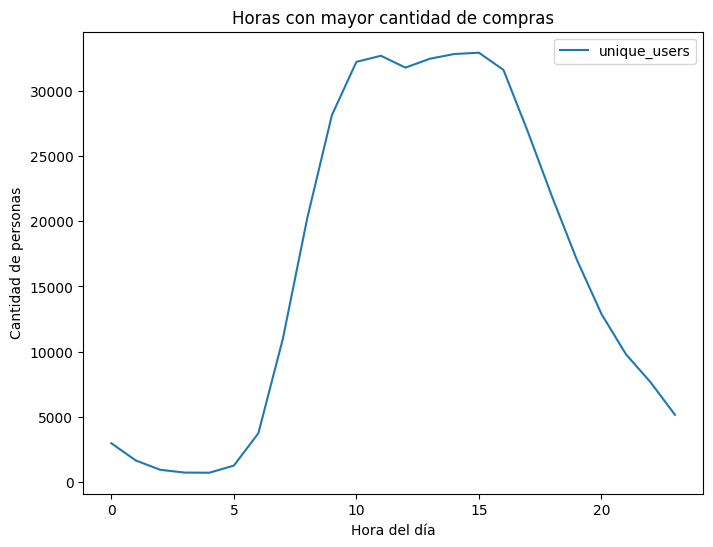

In [44]:
from matplotlib import pyplot as plt
users_ph = instacart_orders.groupby("order_hour_of_day")["user_id"].nunique().reset_index()
users_ph.columns = ['order_hour_of_day', 'unique_users']
print(users_ph.sort_values('order_hour_of_day'))



users_ph.plot(
    title="Horas con mayor cantidad de compras",
    x="order_hour_of_day",
    y="unique_users",
    kind="line",
    figsize=[8, 6],
    xlabel="Hora del día",
    ylabel="Cantidad de personas"
)


 # escribe

Escribe aquí tus conclusiones

### [A3] ¿Qué día de la semana compran víveres las personas?

   day_of_order  unique_users
0             0         57661
1             1         56479
2             2         48587
3             3         45331
4             4         44281
5             5         46127
6             6         45604


<AxesSubplot:title={'center':'Días con mayores compras'}, xlabel='Día de la semana', ylabel='Cantidad de personas'>

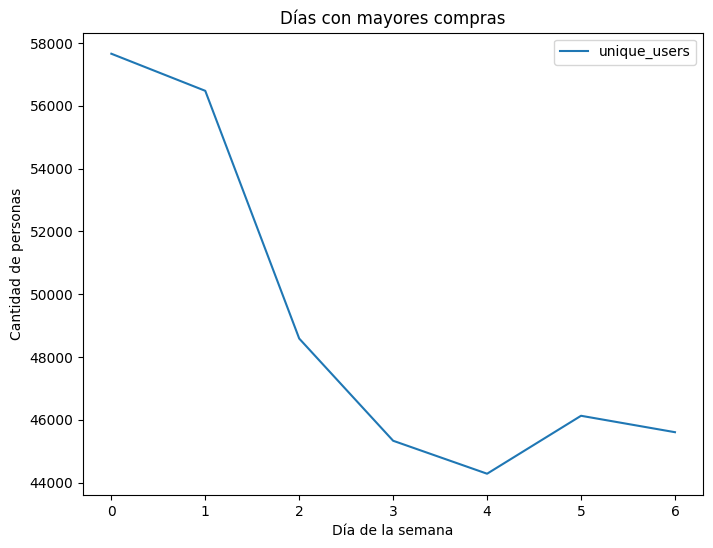

In [45]:
from matplotlib import pyplot as plt
users_pd = instacart_orders.groupby("order_dow")["user_id"].nunique().reset_index()
users_pd.columns = ['day_of_order', 'unique_users']
print(users_pd.sort_values('day_of_order'))
users_pd.plot(
    title="Días con mayores compras",
    x="day_of_order",
    y="unique_users",
    kind="line",
    figsize=[8, 6],
    xlabel="Día de la semana",
    ylabel="Cantidad de personas"
)

Escribe aquí tus conclusiones

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

    days_since_last_order  unique_users
26                   26.0          2620
29                   29.0          2647
25                   25.0          2690
27                   27.0          2961
24                   24.0          2974
23                   23.0          3285
28                   28.0          3684
22                   22.0          4439
19                   19.0          4835
18                   18.0          4896
20                   20.0          5187
17                   17.0          5368
21                   21.0          6276
16                   16.0          6411
0                     0.0          7532
15                   15.0          9044
12                   12.0         10177
11                   11.0         10847
13                   13.0         11172
10                   10.0         12412
14                   14.0         13080
1                     1.0         13286
9                     9.0         15354
2                     2.0         17552


<AxesSubplot:title={'center':'Días desde la ultima compra'}, xlabel='Días de la última compra', ylabel='Cantidad de personas'>

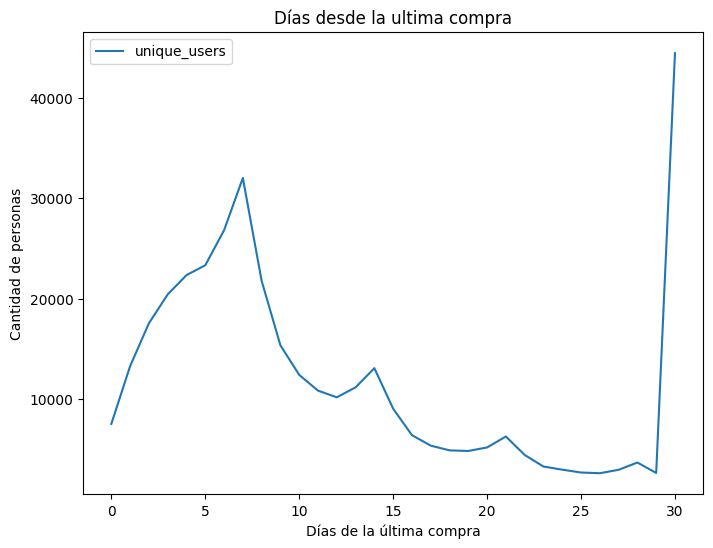

In [46]:
from matplotlib import pyplot as plt
users_dolo = instacart_orders.groupby("days_since_prior_order")["user_id"].nunique().reset_index()
users_dolo.columns = ['days_since_last_order', 'unique_users']
print(users_dolo.sort_values('unique_users'))

users_dolo.plot(
    title="Días desde la ultima compra",
    x="days_since_last_order",
    y="unique_users",
    kind="line",
    figsize=[8, 6],
    xlabel="Días de la última compra",
    ylabel="Cantidad de personas"
)



Escribe aquí tus conclusiones

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [47]:
wednesday = instacart_orders[instacart_orders['order_dow'] == 3]
saturday = instacart_orders[instacart_orders['order_dow'] == 6]

In [48]:
orders_wed = wednesday['order_hour_of_day'].value_counts().sort_index()
orders_sat = saturday['order_hour_of_day'].value_counts().sort_index()

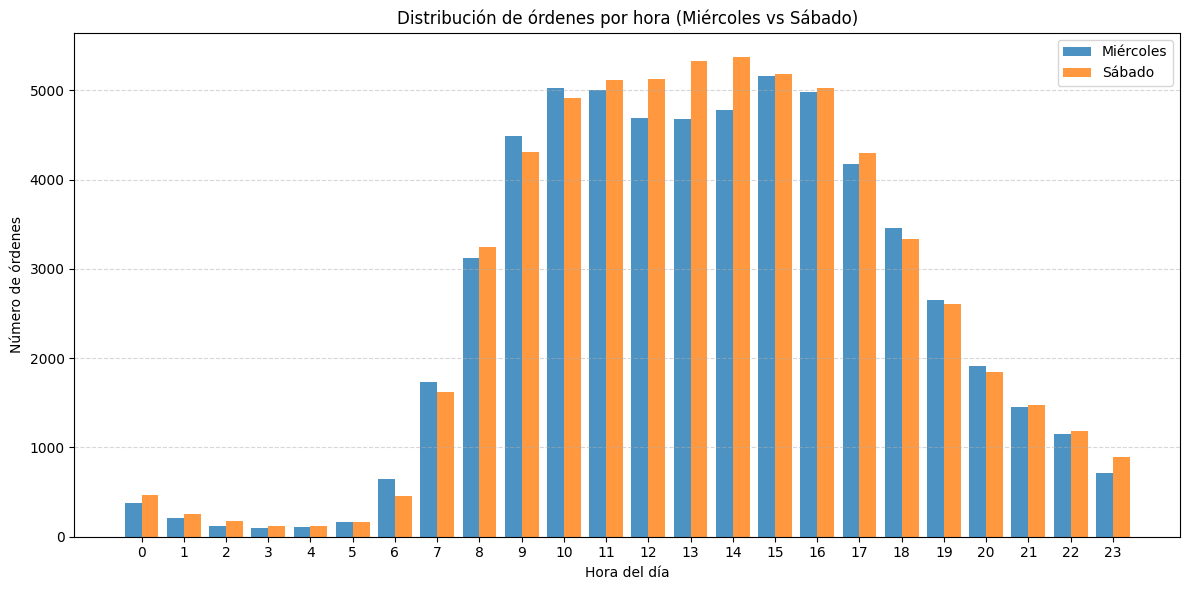

In [49]:
plt.figure(figsize=(12, 6))
plt.bar(orders_wed.index - 0.2, orders_wed.values, width=0.4, label='Miércoles', alpha=0.8)
plt.bar(orders_sat.index + 0.2, orders_sat.values, width=0.4, label='Sábado', alpha=0.8)
plt.title('Distribución de órdenes por hora (Miércoles vs Sábado)')
plt.xlabel('Hora del día')
plt.ylabel('Número de órdenes')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Escribe aquí tus conclusiones

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

user_id
2         2
4         2
5         1
6         2
7         2
         ..
206203    1
206206    7
206207    5
206208    9
206209    2
Name: order_id, Length: 157437, dtype: int64


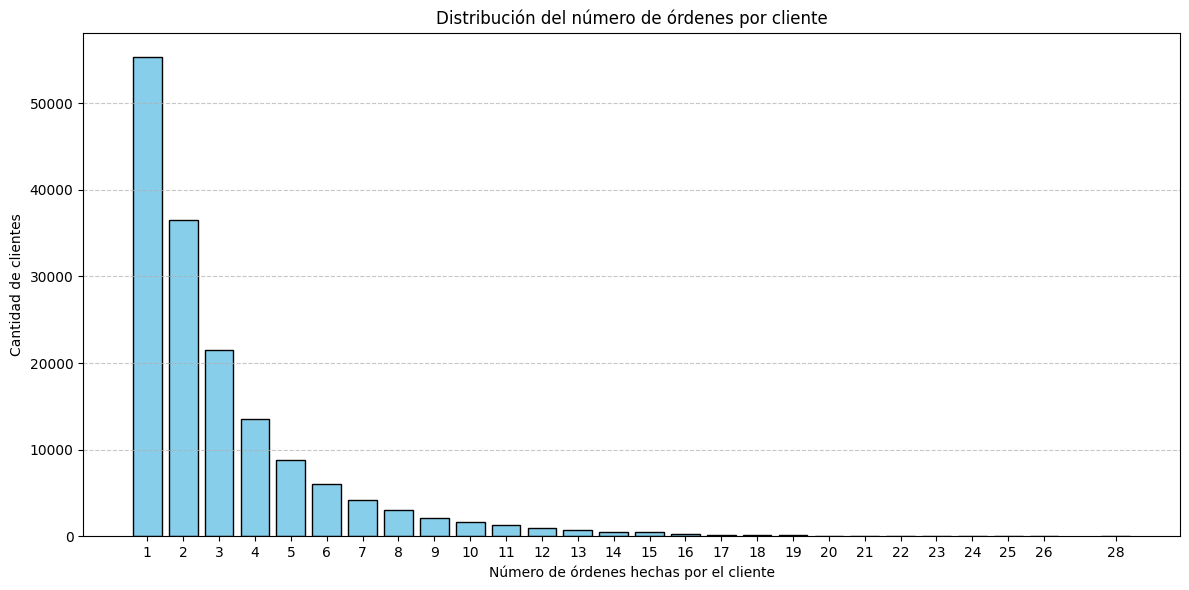

In [50]:
import matplotlib.pyplot as plt
users_npcx = instacart_orders.groupby("user_id")["order_id"].nunique()
order_counts = users_npcx.value_counts().sort_index()
print(users_npcx)

plt.figure(figsize=(12, 6))
plt.bar(order_counts.index, order_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribución del número de órdenes por cliente')
plt.xlabel('Número de órdenes hechas por el cliente')
plt.ylabel('Cantidad de clientes')
plt.xticks(order_counts.index)  # mostrar todos los valores del eje x
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [51]:
product_counts = order_products['product_id'].value_counts().reset_index()
product_counts.columns = ['product_id', 'num_orders']
popular_products = pd.merge(product_counts, products, on='product_id')
top_20_products = popular_products.head(20)
print(top_20_products[['product_id', 'product_name', 'num_orders']])

    product_id              product_name  num_orders
0        24852                    Banana       66050
1        13176    Bag of Organic Bananas       53297
2        21137      Organic Strawberries       37039
3        21903      Organic Baby Spinach       33971
4        47209      Organic Hass Avocado       29773
5        47766           Organic Avocado       24689
6        47626               Large Lemon       21495
7        16797              Strawberries       20018
8        26209                     Limes       19690
9        27845        Organic Whole Milk       19600
10       27966       Organic Raspberries       19197
11       22935      Organic Yellow Onion       15898
12       24964            Organic Garlic       15292
13       45007          Organic Zucchini       14584
14       39275       Organic Blueberries       13879
15       49683            Cucumber Kirby       13675
16       28204        Organic Fuji Apple       12544
17        5876             Organic Lemon      

Escribe aquí tus conclusiones

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Length: 450046, dtype: int64


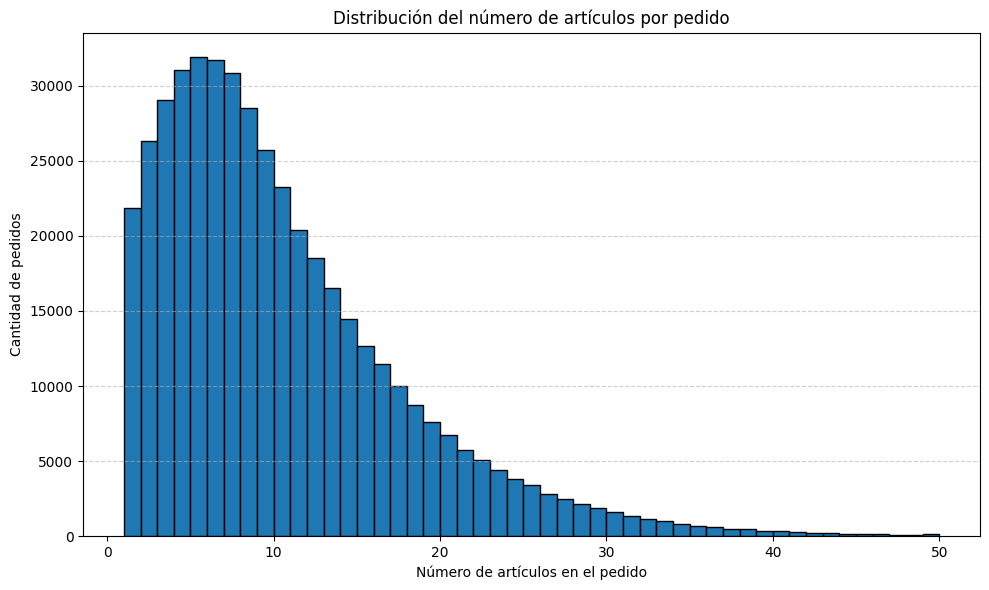

In [52]:
import matplotlib.pyplot as plt
items_per_order = order_products.groupby('order_id').size()
print(items_per_order)


plt.figure(figsize=(10, 6))
plt.hist(items_per_order, bins=range(1, 51), edgecolor='black')  # hasta 50 artículos por claridad
plt.title('Distribución del número de artículos por pedido')
plt.xlabel('Número de artículos en el pedido')
plt.ylabel('Cantidad de pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Escribe aquí tus conclusiones

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [55]:
reordered = order_products[order_products['reordered'] == 1]
top_reordered = (
    reordered['product_id']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'index': 'product_id', 'product_id': 'reorder_count'})
)
top_products = top_reordered.merge(products, on='product_id')[['product_id', 'product_name', 'reorder_count']]
print(top_products)

    product_id              product_name  reorder_count
0        24852                    Banana          55763
1        13176    Bag of Organic Bananas          44450
2        21137      Organic Strawberries          28639
3        21903      Organic Baby Spinach          26233
4        47209      Organic Hass Avocado          23629
5        47766           Organic Avocado          18743
6        27845        Organic Whole Milk          16251
7        47626               Large Lemon          15044
8        27966       Organic Raspberries          14748
9        16797              Strawberries          13945
10       26209                     Limes          13327
11       22935      Organic Yellow Onion          11145
12       24964            Organic Garlic          10411
13       45007          Organic Zucchini          10076
14       49683            Cucumber Kirby           9538
15       28204        Organic Fuji Apple           8989
16        8277  Apple Honeycrisp Organic        

Escribe aquí tus conclusiones

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [58]:
total_orders = order_products.groupby('product_id').size().reset_index(name='total_orders')
reorders = order_products[order_products['reordered'] == 1].groupby('product_id').size().reset_index(name='reorder_count')
product_reorder_stats = pd.merge(total_orders, reorders, on='product_id', how='left')
product_reorder_stats['reorder_count'] = product_reorder_stats['reorder_count'].fillna(0)
product_reorder_stats['reorder_ratio'] = product_reorder_stats['reorder_count'] / product_reorder_stats['total_orders']
product_reorder_stats = product_reorder_stats.merge(products, on='product_id')[['product_id', 'product_name', 'total_orders', 'reorder_count', 'reorder_ratio']]
print(product_reorder_stats.sort_values(by='reorder_ratio', ascending=False).head(10))


       product_id                                       product_name  \
13453       14721                            Bone Strength Take Care   
19195       20949                           Vanilla Sandwich Cookies   
6136         6723                                   Palmiers- Petite   
6144         6732                  Naturally Sparkling Mineral Water   
41319       45088  California Dill Pollen & Garlic Goat Cheese & ...   
41310       45078                                       Pomegranatea   
19258       21016       Parchment Lined 8 in x 3.75 in x 2.5 in Pans   
19248       21005                        Peanut Butter Pie Ice Cream   
32273       35192                         Chocolate Soy Milk Singles   
32277       35197  Mocha Chocolate Chip  Organic Non-Dairy Frozen...   

       total_orders  reorder_count  reorder_ratio  
13453             1            1.0            1.0  
19195             3            3.0            1.0  
6136             10           10.0            1.0  

Escribe aquí tus conclusiones

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [63]:

merged = pd.merge(order_products, instacart_orders[['order_id', 'user_id']], on='order_id')
user_reorder_stats = merged.groupby('user_id').agg(
    total_products=('product_id', 'count'),
    reordered_products=('reordered', 'sum')
).reset_index()
user_reorder_stats['reorder_ratio'] = user_reorder_stats['reordered_products'] / user_reorder_stats['total_products']
print(user_reorder_stats.head())


   user_id  total_products  reordered_products  reorder_ratio
0        2              26                   1       0.038462
1        4               2                   0            0.0
2        5              12                   8       0.666667
3        6               4                   0            0.0
4        7              14                  13       0.928571


Escribe aquí tus conclusiones

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [65]:
first_added = order_products[order_products['add_to_cart_order'] == 1]
first_counts = (
    first_added['product_id']
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={'index': 'product_id', 'product_id': 'first_added_count'})
)

top_first_added = pd.merge(first_counts, products[['product_id', 'product_name']], on='product_id')
print(top_first_added[['product_id', 'product_name', 'first_added_count']])



    product_id                 product_name  first_added_count
0        24852                       Banana              15562
1        13176       Bag of Organic Bananas              11026
2        27845           Organic Whole Milk               4363
3        21137         Organic Strawberries               3946
4        47209         Organic Hass Avocado               3390
5        21903         Organic Baby Spinach               3336
6        47766              Organic Avocado               3044
7        19660                 Spring Water               2336
8        16797                 Strawberries               2308
9        27966          Organic Raspberries               2024
10       44632   Sparkling Water Grapefruit               1914
11       49235          Organic Half & Half               1797
12       47626                  Large Lemon               1737
13         196                         Soda               1733
14       38689     Organic Reduced Fat Milk            

Escribe aquí tus conclusiones

### Conclusion general del proyecto: